Fetching S%26P_500 …
[OK] S%26P_500: (2558, 1) -> cached
Fetching Stock_market …
[OK] Stock_market: (2558, 1) -> cached
Pageviews shape: (2558, 2)
            pv_S%26P_500  pv_Stock_market
timestamp                                
2024-12-30          3965             1209
2024-12-31          4211             1160
2025-01-01          4000             1081
Merged shape: (1760, 9)
X/y shapes: (1759, 2) (1759,)
First feature cols: ['d_pv_S%26P_500', 'd_pv_Stock_market']
Test accuracy: 0.582
              precision    recall  f1-score   support

           0      0.000     0.000     0.000       147
           1      0.582     1.000     0.736       205

    accuracy                          0.582       352
   macro avg      0.291     0.500     0.368       352
weighted avg      0.339     0.582     0.429       352

Saved: /Users/namnguyen/Documents/GitHub/Lesson_7/altdata_outputs/wiki_ivv_merged_features.csv


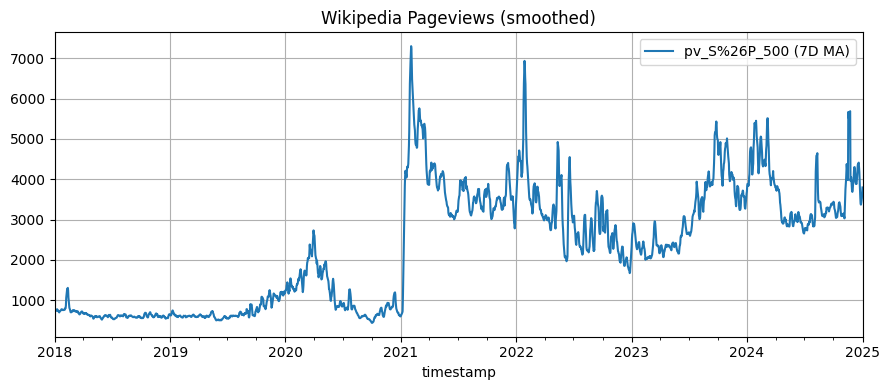

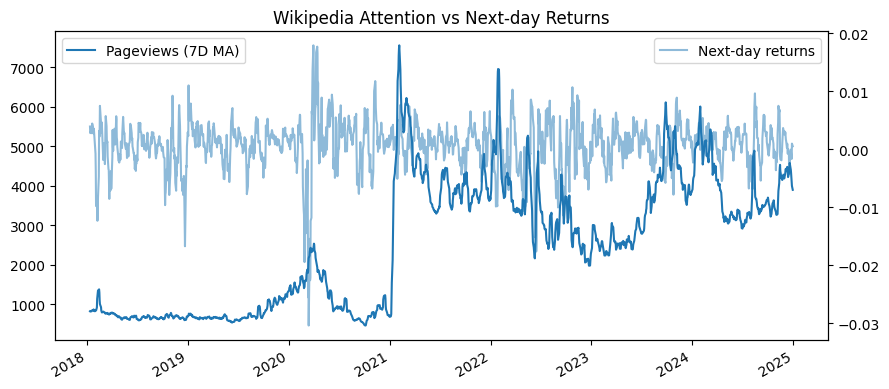

PNG outputs saved to: /Users/namnguyen/Documents/GitHub/Lesson_7/altdata_outputs


In [10]:
# %pip -q install requests yfinance scikit-learn matplotlib pandas --upgrade

import warnings; warnings.filterwarnings("ignore")
import requests, time, random
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from pathlib import Path

# =========================
# CONFIG
# =========================
ARTICLES = [
    ("en.wikipedia.org", "S%26P_500"),   # "S&P 500" (URL-encoded)
    ("en.wikipedia.org", "Stock_market"),
    # ("en.wikipedia.org", "BlackRock"), # optional: uncomment to add
]
START = "2018-01-01"
END   = "2025-01-01"
ACCESS = "all-access"   # desktop+mobile
AGENT  = "user"
GRAN   = "daily"
OUT = Path("altdata_outputs"); OUT.mkdir(exist_ok=True)
HEADERS = {"User-Agent": "WQU-MScFE-AltData-Guide/1.0 (student@example.com)"}

# =========================
# HELPERS
# =========================
def fmt_date(d): 
    return pd.to_datetime(d).strftime("%Y%m%d")

def fetch_wiki_pageviews(project: str, article: str, start: str, end: str,
                         access: str = ACCESS, agent: str = AGENT, gran: str = GRAN) -> pd.DataFrame:
    """Fetch daily pageviews for a single article; returns DataFrame (index=date, column=pv_<article>)."""
    url = (
        "https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/"
        f"{project}/{access}/{agent}/{article}/{gran}/{start}/{end}"
    )
    r = requests.get(url, headers=HEADERS, timeout=30)
    if r.status_code != 200:
        print(f"[WARN] {article} -> HTTP {r.status_code}")
        return pd.DataFrame()
    js = r.json()
    items = js.get("items", [])
    if not items:
        print(f"[WARN] {article} -> empty items")
        return pd.DataFrame()
    df = pd.DataFrame(items)
    # timestamp is YYYYMMDDHH (hour = 00 for daily)
    df["timestamp"] = pd.to_datetime(df["timestamp"], format="%Y%m%d%H")
    df = df.set_index("timestamp")[["views"]].rename(columns={"views": f"pv_{article}"})
    return df

def ensure_ohlcv(df: pd.DataFrame, ticker: str | None = None) -> pd.DataFrame:
    """Normalize yfinance output; collapse MultiIndex; synthesize Adj Close if missing."""
    if isinstance(df.columns, pd.MultiIndex):
        if ticker in df.columns.get_level_values(0):
            df = df[ticker]
        elif ticker in df.columns.get_level_values(1):
            df = df.xs(ticker, axis=1, level=1)
    df = df.rename(columns={c: c.strip().title() for c in df.columns})
    if "Adj Close" not in df.columns and "Close" in df.columns:
        df["Adj Close"] = df["Close"]
    keep = [c for c in ["Open","High","Low","Close","Adj Close","Volume"] if c in df.columns]
    return df[keep].copy()

# =========================
# 1) FETCH WIKIPEDIA PAGEVIEWS (with cache)
# =========================
s_start, s_end = fmt_date(START), fmt_date(END)
series = []
for proj, article in ARTICLES:
    cache = OUT / f"pv_{article}_{s_start}_{s_end}.csv"
    if cache.exists():
        ts = pd.read_csv(cache, index_col=0, parse_dates=True)
        print(f"[CACHE] {article}: {ts.shape}")
    else:
        print(f"Fetching {article} …")
        ts = fetch_wiki_pageviews(proj, article, s_start, s_end)
        if not ts.empty:
            ts.to_csv(cache)
            print(f"[OK] {article}: {ts.shape} -> cached")
        time.sleep(0.5 + random.uniform(0.1,0.4))  # be polite
    if not ts.empty:
        series.append(ts)

if not series:
    raise RuntimeError("No Wikipedia pageviews returned. Try a shorter date window or different article titles.")

pv = pd.concat(series, axis=1).sort_index()
print("Pageviews shape:", pv.shape)
print(pv.tail(3))

# =========================
# 2) MERGE WITH MARKET DATA (yfinance with Adj Close fix)
# =========================
raw = yf.download("IVV", start=START, end=END, progress=False, auto_adjust=False)
if raw.empty:
    raise RuntimeError("IVV download failed (network?).")
ivv = ensure_ohlcv(raw, "IVV")
ivv["ret_1d"] = ivv["Adj Close"].pct_change().shift(-1)

data = ivv.join(pv, how="inner").dropna().copy()
print("Merged shape:", data.shape)

# =========================
# 3) FEATURE ENGINEERING (attention changes)
# =========================
for c in [col for col in data.columns if col.startswith("pv_")]:
    data[f"d_{c}"] = data[c].pct_change()   # scale-free attention shocks
data = data.dropna().copy()

X = data[[c for c in data.columns if c.startswith("d_pv_")]].copy()
y = (data["ret_1d"] > 0).astype(int)

print("X/y shapes:", X.shape, y.shape)
print("First feature cols:", list(X.columns)[:5])

# =========================
# 4) TIME-ORDERED TRAIN/TEST & SIMPLE MODEL
# =========================
split = int(len(X)*0.8)
Xtr, Xte = X.iloc[:split], X.iloc[split:]
ytr, yte = y.iloc[:split], y.iloc[split:]

clf = LogisticRegression(max_iter=1000)
clf.fit(Xtr, ytr)
pred = clf.predict(Xte)
acc = accuracy_score(yte, pred)
print("Test accuracy:", round(acc, 3))
print(classification_report(yte, pred, digits=3))

# Save merged data and predictions
out_csv = OUT / "wiki_ivv_merged_features.csv"
data.assign(y=y, y_pred=pd.Series(index=data.index, dtype=float)).to_csv(out_csv)
print("Saved:", out_csv.resolve())

# =========================
# 5) PLOTS (+ save PNGs)
# =========================
# a) Smoothed pageviews (first series)
plt.figure(figsize=(9,4))
first_pv_col = pv.columns[0]
pv[first_pv_col].rolling(7).mean().plot(label=f"{first_pv_col} (7D MA)")
plt.title("Wikipedia Pageviews (smoothed)")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(OUT/"wiki_pageviews_smoothed.png", dpi=150); plt.show()

# b) Pageviews vs next-day returns
fig, ax1 = plt.subplots(figsize=( nine := 9, four := 4))
data[first_pv_col].rolling(7).mean().plot(ax=ax1, label="Pageviews (7D MA)")
ax2 = ax1.twinx()
data["ret_1d"].rolling(7).mean().plot(ax=ax2, alpha=0.5, label="Next-day returns")
ax1.set_title("Wikipedia Attention vs Next-day Returns")
ax1.legend(loc="upper left"); ax2.legend(loc="upper right")
fig.tight_layout()
fig.savefig(OUT/"wiki_vs_returns.png", dpi=150)
plt.show()

print("PNG outputs saved to:", OUT.resolve())